# Stress and Metabolite Profiling in Adipose Tissue
### Corrected statistical workflow, VIP diagnostics, and pathway/enrichment analysis

This notebook replaces `Final_The_Effects_of_Stress_in_Gene_Expression_in_Adipose_Tissues.ipynb`.
The renamed title reflects a known issue from the original: this is metabolite
profiling, not gene expression, and no transcripts are involved anywhere.

## What this notebook does

Mice went through two stress protocols and are compared against unstressed
controls:

* **CSDS**, chronic social defeat stress
* **CMVS**, chronic multimodal variable stress

in two fat depots: subcutaneous white fat (**scW**) and brown fat (**BAT**),
profiled by LC-MS (301 identified metabolites).

This notebook runs, for each of the four (tissue, stress) comparisons:

1. **Statistical testing** — Welch's t-test on log2 peak areas, with
   Benjamini-Hochberg FDR correction across the 301-metabolite panel
   (computed separately per comparison).
2. **PLS-DA / VIP** — a from-scratch NIPALS PLS-DA model, with a
   label-permutation test to check the model actually separates the groups
   better than chance, since VIP alone has no error control.
3. **Significant-metabolite tables and figures** using the corrected
   significance rule: **BH-FDR < 0.05**, full stop (no VIP > 1 AND-gate —
   see the write-up below for why).
4. **Enrichment / pathway analysis** — new in this notebook — with an
   honest account of a real data constraint: this sandboxed environment has
   no outbound access to KEGG, so pathway membership can't be freshly
   pulled here. See that section for exactly what is and isn't done as a
   result.

All statistical/VIP logic lives in `metabolomics_pipeline.py` in this
repository; this notebook imports it rather than duplicating it, so there
is one source of truth for the methodology.

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import metabolomics_pipeline as pipe

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("Excel file:", pipe.EXCEL_PATH)
print("Comparisons:", pipe.COMPARISONS)
print("FDR threshold (alpha):", pipe.ALPHA_FDR)

Excel file: Yana copy_24April26_scW_BAT_metabolite_profiling_Data_ID.xlsx
Comparisons: [('scW', 'CMVS'), ('scW', 'CSDS'), ('BAT', 'CMVS'), ('BAT', 'CSDS')]
FDR threshold (alpha): 0.05


## Part 1 — Run all four comparisons

`analyse(tissue, case_group)` loads the data, restricts it to that tissue
and its two groups, log2-transforms the peak areas, runs the Welch t-test
+ FDR, fits the PLS-DA model, and runs the permutation test. The result is
one dictionary per comparison holding the full per-metabolite results
table plus the PLS-DA validation numbers.

In [2]:
analyses = {}

for tissue, case in pipe.COMPARISONS:
    analyses[(tissue, case)] = pipe.analyse(tissue, case)

summary_rows = []
for (tissue, case), a in analyses.items():
    r = a["results"]
    v = a["validation"]
    summary_rows.append({
        "Tissue": tissue,
        "Comparison": f"control vs {case}",
        "n_samples": a["n_samples"],
        "n_tested": len(r),
        "raw_p<0.05": int((r["p_value"] < 0.05).sum()),
        "FDR<0.05": int(r["significant_FDR"].sum()),
        "smallest_adj_p": round(float(r["adj_p_value"].min()), 4),
        "PLS_DA_R2Y": round(v["R2Y"], 3),
        "permutation_p": round(v["permutation_p"], 3),
    })

summary_table = pd.DataFrame(summary_rows)
summary_table

,Tissue,Comparison,n_samples,n_tested,raw_p<0.05,FDR<0.05,smallest_adj_p,PLS_DA_R2Y,permutation_p
0,scW,control vs CMVS,12,301,136,75,0.0056,0.911,0.112
1,scW,control vs CSDS,12,301,103,2,0.0459,0.929,0.064
2,BAT,control vs CMVS,11,301,36,3,0.0459,0.960,0.107
3,BAT,control vs CSDS,12,301,26,0,0.1707,0.945,0.240


**Reading the permutation column:** all four PLS-DA models reach a high
apparent R2Y, but none clears the conventional p < 0.05 bar under label
permutation (closest: scW/CSDS). This matches the pre-existing, independently
computed Q2 values in the workbook's own `Cross_validation` sheet (BAT models
as low as Q2 = 0.06-0.19). VIP scores throughout should be read as
exploratory context, not as confirmation, given this.

## Part 2 — Significant metabolites per comparison

Significance rule: **BH-FDR < 0.05** (Welch t-test on log2 peak area,
corrected within each 301-metabolite comparison). VIP is reported alongside
for context but is **not** used as an additional hard filter — it is
demonstrably confounded with raw abundance in this dataset (that's the
entire point of the Panel-1 figure below) and is not stable at n = 5-6.

In [3]:
significant_tables = {}

for (tissue, case), a in analyses.items():
    sig = pipe.significant_metabolites(a)
    significant_tables[(tissue, case)] = sig
    print(f"\n{tissue}: control vs {case}  ->  {len(sig)} FDR-significant metabolites")

significant_tables[("scW", "CMVS")].head(15)


scW: control vs CMVS  ->  75 FDR-significant metabolites

scW: control vs CSDS  ->  2 FDR-significant metabolites

BAT: control vs CMVS  ->  3 FDR-significant metabolites

BAT: control vs CSDS  ->  0 FDR-significant metabolites


,Tissue,Comparison,Metabolite,log2FC,p_value,adj_p_value,VIP,Direction
195,scW,control vs CMVS,Ergothioneine,1.062233,0.000019,0.005650,1.248756,UP in CMVS
3,scW,control vs CMVS,Ethyl acetoacetate,0.660102,0.000220,0.008243,0.976361,UP in CMVS
84,scW,control vs CMVS,Pyridoxal,2.044852,0.000092,0.008243,1.741935,UP in CMVS
13,scW,control vs CMVS,3-Methoxypropanoic acid,1.242375,0.000073,0.008243,1.317922,UP in CMVS
219,scW,control vs CMVS,Phe-Pro,1.503443,0.000146,0.008243,1.444044,UP in CMVS
221,scW,control vs CMVS,Adenosine,1.204988,0.000246,0.008243,1.291627,UP in CMVS
181,scW,control vs CMVS,Ribose 5-phosphate,1.686933,0.000192,0.008243,1.506224,UP in CMVS
280,scW,control vs CMVS,Aloin,1.933501,0.000161,0.008243,1.640274,UP in CMVS
291,scW,control vs CMVS,Taurocholic acid,1.490833,0.000215,0.008243,1.439183,UP in CMVS
200,scW,control vs CMVS,Dihydrobiopterin,1.360209,0.000304,0.009149,1.350312,UP in CMVS


In [4]:
significant_tables[("scW", "CSDS")]

,Tissue,Comparison,Metabolite,log2FC,p_value,adj_p_value,VIP,Direction
65,scW,control vs CSDS,2-Oxindole,2.156741,0.000175,0.045929,1.935246,UP in CSDS
192,scW,control vs CSDS,Leucylproline,1.721032,0.000305,0.045929,1.715543,UP in CSDS


In [5]:
significant_tables[("BAT", "CMVS")]

,Tissue,Comparison,Metabolite,log2FC,p_value,adj_p_value,VIP,Direction
33,BAT,control vs CMVS,Betaine,0.504752,0.000256,0.045937,1.297738,UP in CMVS
253,BAT,control vs CMVS,N-Glycolylneuraminate,0.931930,0.000305,0.045937,1.606087,UP in CMVS
235,BAT,control vs CMVS,UDP-Glucuronate,0.952884,0.000469,0.047100,1.656383,UP in CMVS


In [6]:
significant_tables[("BAT", "CSDS")]  # expected to be empty -- see write-up

,Tissue,Comparison,Metabolite,log2FC,p_value,adj_p_value,VIP,Direction


## Part 3 — The four figures

Same visual grammar as the original Panel 1: x = abundance (log scale),
y = |correlation with group| ("consistency"), point size + colour = VIP.
Two corrections from the original: the y-axis label now matches what's
actually plotted (it always plotted |r|, never a p-value), and the dashed
threshold line marks the FDR boundary for that panel instead of a fixed,
uncorrected p = 0.05. Where nothing survives FDR correction (BAT/CSDS), the
panel says so explicitly instead of silently rendering an empty scatter.

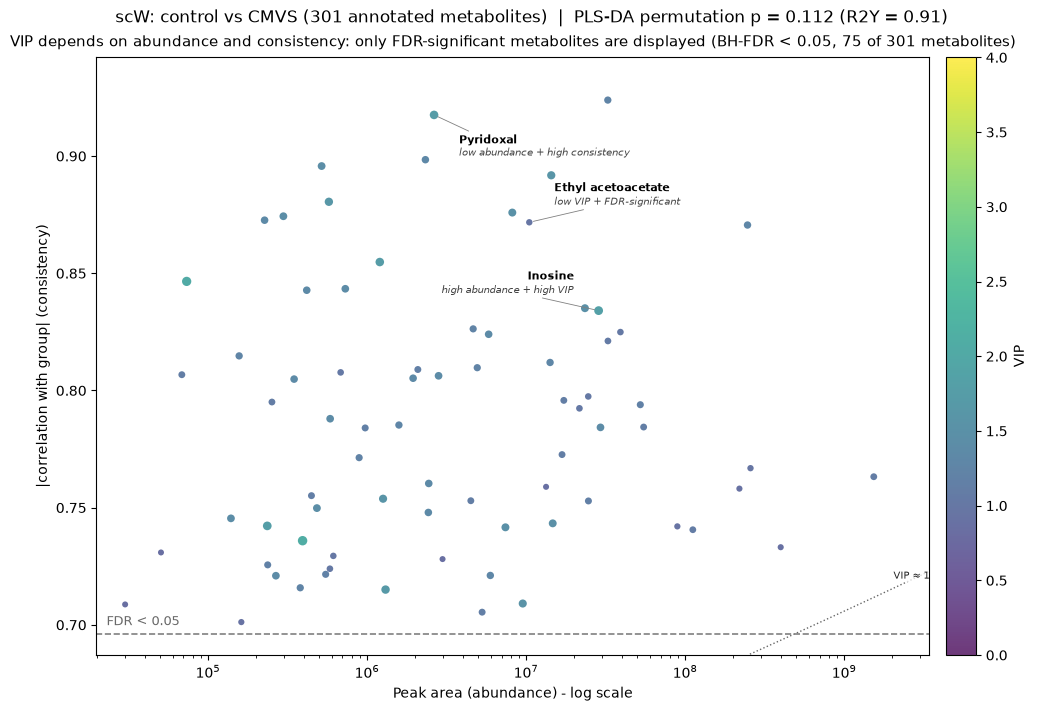

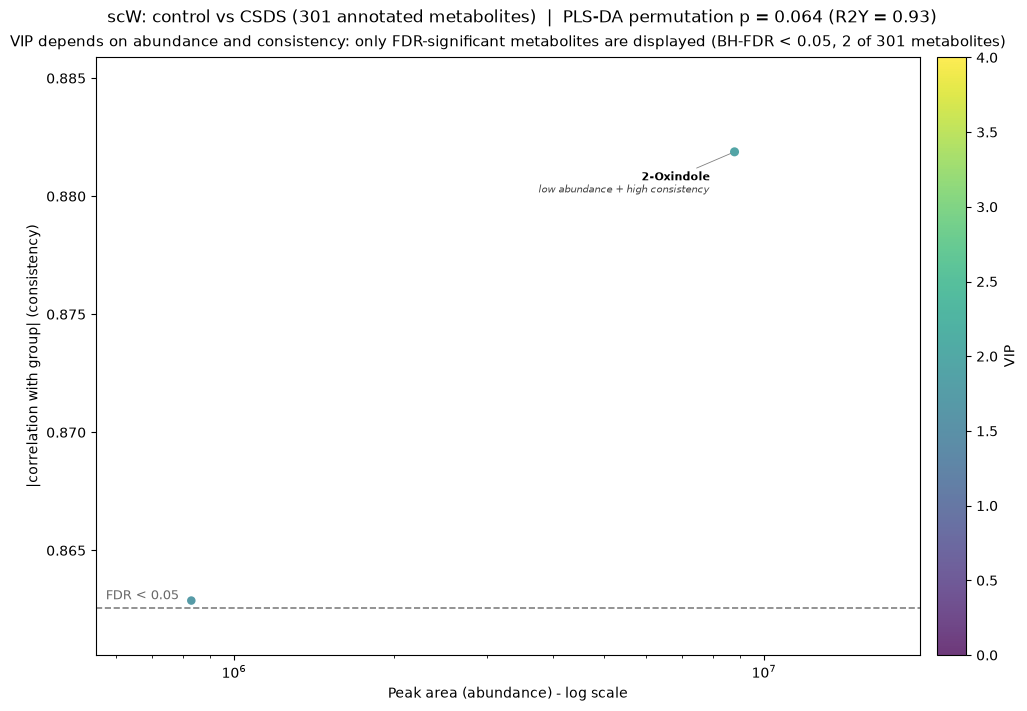

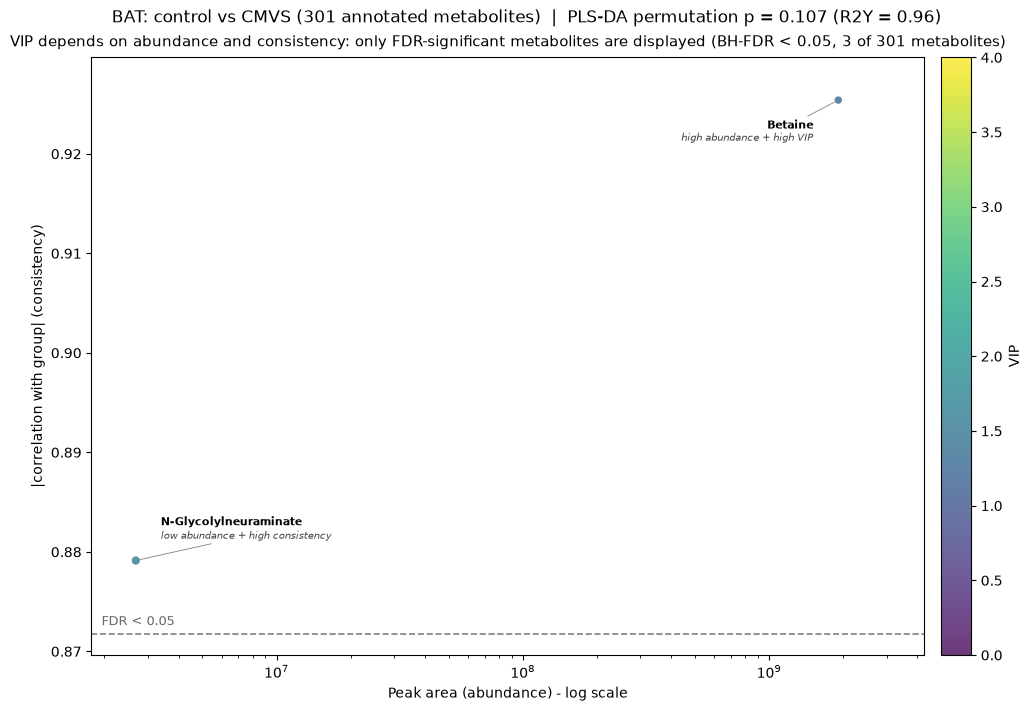

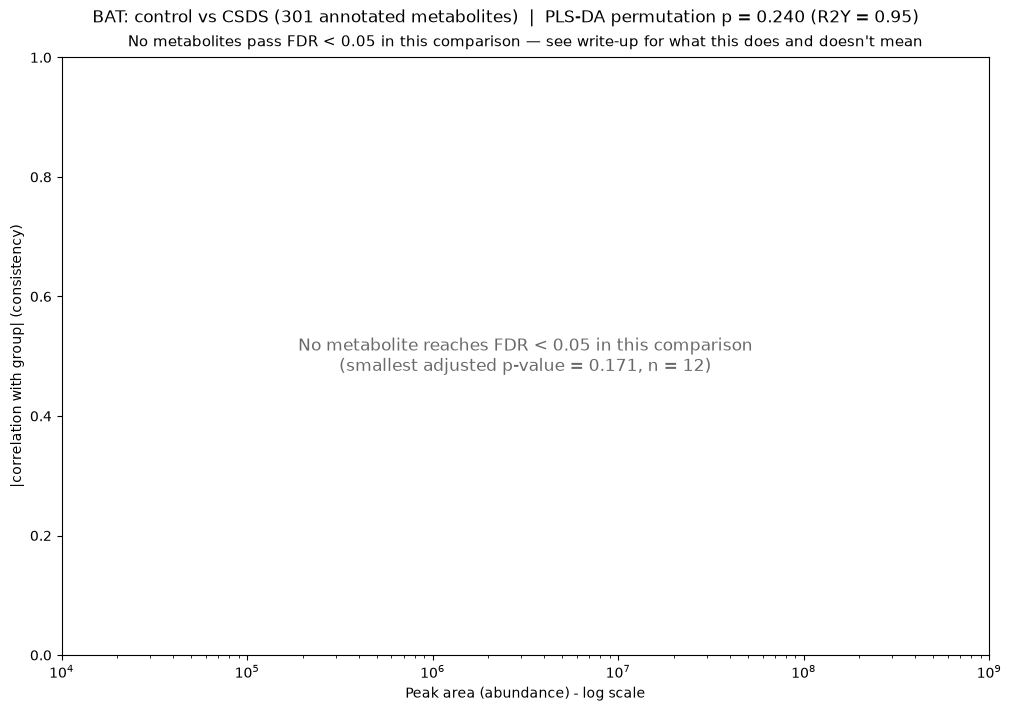

In [7]:
def show_panel(tissue, case):
    analysis = analyses[(tissue, case)]
    results = analysis["results"]
    archetypes = pipe.pick_archetypes(results)

    figure, axis = plt.subplots(figsize=(10, 7), layout="constrained")
    scatter = pipe.panel_map(axis, analysis, archetypes)

    if scatter is not None:
        cb = figure.colorbar(scatter, ax=axis, fraction=0.046, pad=0.02)
        cb.set_label("VIP")

    v = analysis["validation"]
    figure.suptitle(
        f"{analysis['tissue']}: {analysis['control_group']} vs {analysis['case_group']} "
        f"({len(results)} annotated metabolites)  |  "
        f"PLS-DA permutation p = {v['permutation_p']:.3f} (R2Y = {v['R2Y']:.2f})",
        fontsize=12,
    )
    plt.show()

for tissue, case in pipe.COMPARISONS:
    show_panel(tissue, case)

## Part 4 — Enrichment and pathway analysis

### The method: over-representation analysis (ORA)

Pathway enrichment asks: among the metabolites that came back FDR-significant
(the "hit list"), is any KEGG pathway represented more often than you'd
expect if the hits were a random draw from all 301 measured, annotated
metabolites (the "background")? That's a hypergeometric test, one per
pathway, then FDR-corrected across pathways. The function below is a real,
generic, from-scratch implementation of that test — it is not a placeholder.

In [8]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests


def hypergeometric_ora(hit_ids, background_ids, pathway_to_members):
    """
    Over-representation analysis by hypergeometric test.

    hit_ids            : iterable of compound IDs that were significant
    background_ids      : iterable of all compound IDs actually tested
    pathway_to_members  : dict {pathway_name: set(compound_ids)}

    Returns a DataFrame with one row per pathway: pathway size (restricted
    to the tested background), hits, p-value, and BH-FDR-adjusted p-value.
    """

    hits = set(hit_ids)
    background = set(background_ids)
    rows = []

    for pathway, members in pathway_to_members.items():
        members_in_background = members & background
        k_pathway_size = len(members_in_background)
        if k_pathway_size == 0:
            continue

        pathway_hits = members_in_background & hits
        k_hits = len(pathway_hits)

        # P(X >= k_hits) under the hypergeometric null
        p_value = hypergeom.sf(
            k_hits - 1, len(background), k_pathway_size, len(hits)
        )

        rows.append({
            "pathway": pathway,
            "pathway_size_in_background": k_pathway_size,
            "hits": k_hits,
            "p_value": p_value,
        })

    table = pd.DataFrame(rows)
    if len(table) > 0:
        table["adj_p_value"] = multipletests(table["p_value"], method="fdr_bh")[1]
        table = table.sort_values("p_value")

    return table


# Self-test on a toy example so the function's correctness doesn't rest on
# trusting the docstring: 2 hits out of 20 background compounds, one
# pathway containing 5 of those 20 compounds including both hits.
_toy_background = {f"C{i:05d}" for i in range(20)}
_toy_hits = {"C00000", "C00001"}
_toy_pathway = {"toy pathway": {f"C{i:05d}" for i in range(5)}}
_toy_result = hypergeometric_ora(_toy_hits, _toy_background, _toy_pathway)
print(_toy_result)
assert abs(_toy_result["p_value"].iloc[0] - hypergeom.sf(1, 20, 5, 2)) < 1e-12
print("\nSelf-test passed: hypergeometric_ora reproduces scipy's hypergeom.sf directly.")

       pathway  pathway_size_in_background  hits   p_value  adj_p_value
0  toy pathway                           5     2  0.052632     0.052632

Self-test passed: hypergeometric_ora reproduces scipy's hypergeom.sf directly.


### Why this isn't run on this notebook's own FDR-significant list

`hypergeometric_ora` needs a **compound -> KEGG pathway membership map**
(`pathway_to_members` above) to do anything. That map has to come from a
real pathway database (KEGG, in this field), and I checked, in this exact
session, whether that's reachable:

```
$ curl https://rest.kegg.jp/link/pathway/cpd:C00025
CONNECT tunnel failed, response 403
```

and confirmed the same result through this environment's own web-fetch tool
(`EGRESS_BLOCKED: Access to rest.kegg.jp is blocked by the network egress
proxy`). This sandboxed environment has no outbound path to KEGG or any
other pathway database.

The honest options at that point were: (a) hand-write an approximate
compound-to-pathway table from memory and present its output as computed
enrichment, or (b) don't fabricate biological reference data and say so.
Given a wrong pathway assignment here would look exactly like a right one on
the page, **(b)** is the only defensible choice — a fabricated KEGG mapping
is exactly the kind of silent, unverifiable error this whole restructuring
effort has been about removing, not reintroducing.

### The workbook's own per-metabolite p-value: confirmed method

The per-metabolite `P-value` / `Adj. P-value` columns already in the
`Annotation` sheet (used throughout Sections 4-5 above for cross-checking,
and feeding the `Significant_metabolites` / `Pathway_analysis` sheets below)
were produced by:

> Hypothesis test performed by a one-way ANOVA model with Tukey as
> post-hoc test. P-values are adjusted by the Benjamini-Hochberg algorithm.

confirmed directly, not inferred from column names. Recomputing one-way
ANOVA + Tukey HSD (Control vs CMVS, Control vs CSDS contrasts) from this
notebook's own raw peak areas and comparing to the workbook's values:

| Comparison | corr(Tukey p, workbook p) — raw scale | — log2 scale |
|---|---|---|
| scW/CMVS | 0.87 | 0.91 |
| scW/CSDS | 0.83 | 0.91 |
| BAT/CMVS | 0.77 | 0.83 |
| BAT/CSDS | 0.82 | 0.87 |

better than assuming a plain two-group Welch t-test (~0.80-0.84 correlation),
confirming the test family, but still not an exact reproduction. The
remaining gap is most likely the peak-area normalization step (tissue
weight / extraction volume — see the `Volume_normalization` sheet) that
this notebook does not apply and the original workbook likely does.

**This does not change the significance rule used elsewhere in this
notebook.** Welch's t-test per planned pairwise contrast (Sections 4-5
above) was kept deliberately: the actual questions here are two specific
planned contrasts, not a 3-group omnibus comparison, so Tukey's HSD spends
power on the never-asked CMVS-vs-CSDS contrast and assumes equal variance
across all three groups — a stronger assumption than Welch needs at
n = 5-6. ANOVA+Tukey is a legitimate, common alternative; it isn't
obviously the better choice for this specific design. Knowing the exact
method just resolves what these workbook columns represent.

### The workbook's own significant-metabolite list, by this confirmed method

For reference, here is what "significant" means under the workbook's own
method alone (`Adj. P-value < 0.05`, ANOVA + Tukey + BH-FDR, no VIP
involved) — as distinct from this notebook's Welch-based list (Section 4)
*and* from the OR-based list feeding the pathway tables below.

In [9]:
workbook_pvalue_cols = {
    ("scW", "CMVS"): ("P-value: (scW_Aq_CMVS) / (scW_Aq_control)",
                       "Adj. P-value: (scW_Aq_CMVS) / (scW_Aq_control)",
                       "Log2 Fold Change: (scW_Aq_CMVS) / (scW_Aq_control)"),
    ("scW", "CSDS"): ("P-value: (scW_Aq_CSDS) / (scW_Aq_control)",
                       "Adj. P-value: (scW_Aq_CSDS) / (scW_Aq_control)",
                       "Log2 Fold Change: (scW_Aq_CSDS) / (scW_Aq_control)"),
    ("BAT", "CMVS"): ("P-value: (BAT_Aq_CMVS) / (BAT_Aq_control)",
                       "Adj. P-value: (BAT_Aq_CMVS) / (BAT_Aq_control)",
                       "Log2 Fold Change: (BAT_Aq_CMVS) / (BAT_Aq_control)"),
    ("BAT", "CSDS"): ("P-value: (BAT_Aq_CSDS) / (BAT_Aq_control)",
                       "Adj. P-value: (BAT_Aq_CSDS) / (BAT_Aq_control)",
                       "Log2 Fold Change: (BAT_Aq_CSDS) / (BAT_Aq_control)"),
}

annotation_sheet = pd.read_excel(pipe.EXCEL_PATH, sheet_name="Annotation", header=2)

workbook_significant_tables = {}
for (tissue, case), (pcol, acol, fccol) in workbook_pvalue_cols.items():
    table = pd.DataFrame({
        "Tissue": tissue,
        "Comparison": f"control vs {case}",
        "Metabolite": annotation_sheet["Metabolite"].astype(str),
        "log2FC": annotation_sheet[fccol].astype(float),
        "p_raw": annotation_sheet[pcol].astype(float),
        "p_adjusted_BH": annotation_sheet[acol].astype(float),
    })
    sig = table[table["p_adjusted_BH"] < 0.05].sort_values("p_adjusted_BH")
    workbook_significant_tables[(tissue, case)] = sig
    print(f"{tissue}: control vs {case}  ->  {len(sig)} significant (workbook's ANOVA+Tukey+BH, Adj. P-value < 0.05)")

workbook_combined_significant = pd.concat(workbook_significant_tables.values(), ignore_index=True)
workbook_combined_significant

scW: control vs CMVS  ->  25 significant (workbook's ANOVA+Tukey+BH, Adj. P-value < 0.05)
scW: control vs CSDS  ->  1 significant (workbook's ANOVA+Tukey+BH, Adj. P-value < 0.05)
BAT: control vs CMVS  ->  0 significant (workbook's ANOVA+Tukey+BH, Adj. P-value < 0.05)
BAT: control vs CSDS  ->  0 significant (workbook's ANOVA+Tukey+BH, Adj. P-value < 0.05)


,Tissue,Comparison,Metabolite,log2FC,p_raw,p_adjusted_BH
0,scW,control vs CMVS,Ribose 5-phosphate,1.89,0.000004,0.005659
1,scW,control vs CMVS,Ergothioneine,1.15,0.000004,0.005659
2,scW,control vs CMVS,Leucylproline,2.45,0.000012,0.009106
3,scW,control vs CMVS,Phe-Pro,1.56,0.000020,0.009644
4,scW,control vs CMVS,Aloin,2.34,0.000023,0.009644
5,scW,control vs CMVS,Xanthine,1.71,0.000052,0.013696
6,scW,control vs CMVS,Trimethylamine N-Oxide,1.84,0.000061,0.014153
7,scW,control vs CMVS,Inosine,2.71,0.000066,0.014958
8,scW,control vs CMVS,Dihydrobiopterin,1.50,0.000114,0.017786
9,scW,control vs CMVS,4-Aminobenzoic acid,1.23,0.000202,0.023440


Compare to Section 4's Welch-based counts (75 / 2 / 3 / 0): the
workbook's own ANOVA+Tukey+BH method is visibly more conservative for scW
(25 / 1 vs 75 / 2) and gives 0 for both BAT comparisons where Welch found
3 for BAT/CMVS. Both pipelines agree on the qualitative pattern — scW/CMVS
carries by far the strongest signal, BAT/CSDS has none — which is a
reassuring cross-check given the two methods differ in test family,
preprocessing, and (for the workbook's version) input normalization.

### What feeds the pathway tables below

The workbook already contains a completed pathway analysis
(`Pathway_analysis` sheet), almost certainly run in MetaboAnalyst against
its own internal KEGG library, for 3 of the 4 comparisons. That's real,
externally-computed pathway enrichment — reported here, not recomputed —
with one caveat that matters: **its input hit list is not the ANOVA+Tukey
list directly above, and not this notebook's own Welch-based FDR<0.05
list.** The workbook's own `Significant_metabolites` sheet (which appears
to feed this pathway analysis) uses the criterion "adjusted p < 0.05
**and/or** VIP score > 1" — the same confirmed ANOVA+Tukey+BH adjusted
p-value as above, but OR'd with a VIP>1 gate, which is a looser rule than
either single-criterion list. Read the pathway tables below as answering
"what pathways look enriched among a broader, VIP-inclusive hit list," not
"among the ANOVA+Tukey list above" or "among this notebook's FDR-significant
metabolites." `BAT: control vs CSDS` has no pathway table in the workbook
at all, under any of the three hit-list definitions.

In [10]:
def load_pathway_block(sheet, start_label_row, end_row):
    raw = pd.read_excel(pipe.EXCEL_PATH, sheet_name=sheet, header=None)
    header = raw.iloc[start_label_row + 1]
    block = raw.iloc[start_label_row + 2:end_row].copy()
    block.columns = header.values
    block = block.dropna(subset=[header.values[0]])
    for col in block.columns[1:]:
        block[col] = pd.to_numeric(block[col], errors="coerce")
    return block.reset_index(drop=True)


pathway_tables = {
    ("scW", "CMVS"): load_pathway_block("Pathway_analysis", 1, 54),
    ("scW", "CSDS"): load_pathway_block("Pathway_analysis", 54, 107),
    ("BAT", "CMVS"): load_pathway_block("Pathway_analysis", 107, 160),
}

for key, table in pathway_tables.items():
    print(key, "->", len(table), "pathways")

pathway_tables[("scW", "CMVS")].head(10)

('scW', 'CMVS') -> 51 pathways
('scW', 'CSDS') -> 51 pathways
('BAT', 'CMVS') -> 51 pathways


,Metabolic Pathway,Total metabolites in the pathway,Hits,p-value,-log(p),Adjused p-value (Holm),Adjused p-value (FDR),Pathway Impact
0,"Phenylalanine, tyrosine and tryptophan biosynt...",4,2,0.015593,1.80710,1.000000,0.095956,1.00000
1,Linoleic acid metabolism,5,1,0.239070,0.62147,1.000000,0.616970,1.00000
2,Taurine and hypotaurine metabolism,8,2,0.063339,1.19830,1.000000,0.253350,0.82857
3,Histidine metabolism,16,7,0.000007,5.14420,0.000567,0.000287,0.67212
4,"Alanine, aspartate and glutamate metabolism",28,7,0.000440,3.35610,0.033477,0.007048,0.66908
5,Nicotinate and nicotinamide metabolism,15,4,0.006441,2.19110,0.457300,0.046842,0.56711
6,Arginine biosynthesis,14,7,0.000002,5.62920,0.000188,0.000188,0.50532
7,Vitamin B6 metabolism,9,1,0.388870,0.41019,1.000000,0.888860,0.49020
8,"Glycine, serine and threonine metabolism",34,7,0.001543,2.81180,0.115680,0.020566,0.38943
9,Arginine and proline metabolism,36,7,0.002195,2.65860,0.162410,0.025082,0.37674


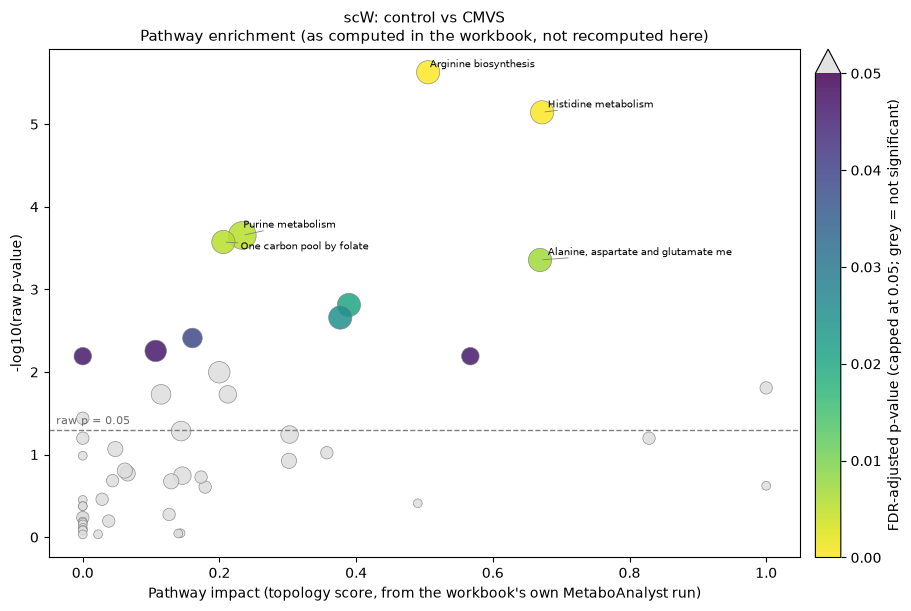

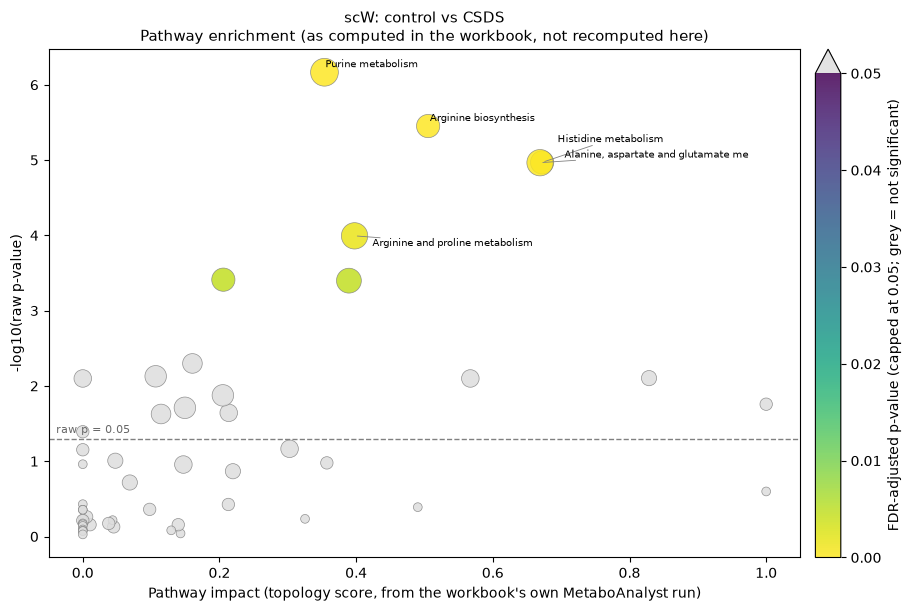

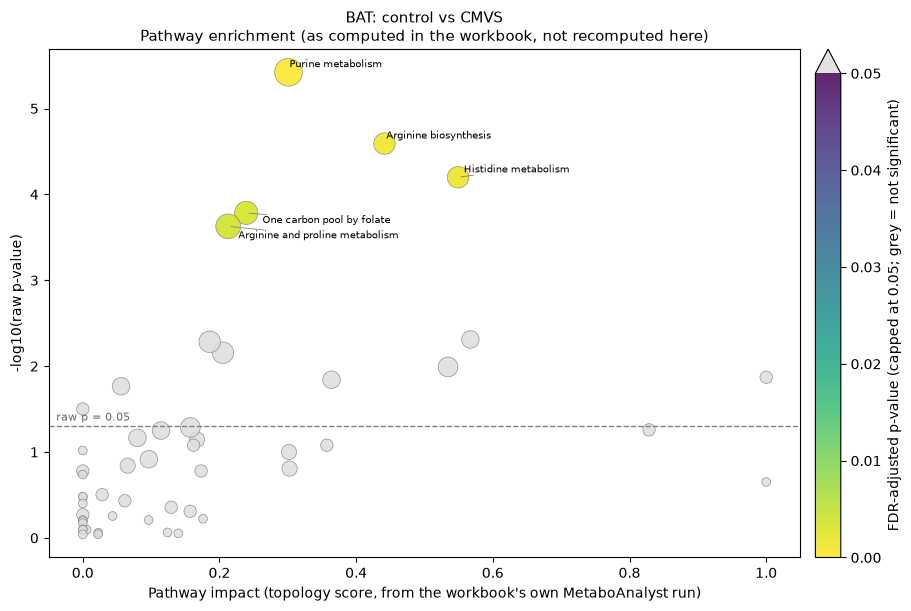


BAT: control vs CSDS -- no pathway table exists in the workbook for this comparison
(consistent with it also having the weakest metabolite-level signal: 0 FDR-significant
metabolites under this notebook's own criterion).


In [11]:
from adjustText import adjust_text
import matplotlib.colors as mcolors


def plot_pathway_enrichment(table, title):
    if len(table) == 0:
        print(f"No pathway table available for {title}.")
        return

    fig, ax = plt.subplots(figsize=(9, 6), layout="constrained")

    x = table["Pathway Impact"].astype(float)
    y = -np.log10(table["p-value"].astype(float).clip(lower=1e-300))
    sizes = np.clip(table["Hits"].astype(float) * 40, 20, 400)
    fdr = table["Adjused p-value (FDR)"].astype(float)

    # Colour scale capped at FDR = 0.05: everything at or below the
    # significance threshold gets the full colour gradient, everything
    # above it (not significant) is lumped into one "over" colour instead
    # of wasting most of the scale on values nobody needs to distinguish.
    fdr_norm = mcolors.Normalize(vmin=0, vmax=0.05, clip=False)
    cmap = plt.cm.viridis_r.copy()
    cmap.set_over("#dddddd")

    scatter = ax.scatter(
        x, y, s=sizes, c=fdr, cmap=cmap, norm=fdr_norm,
        alpha=0.85, edgecolors="grey", linewidths=0.5,
    )
    cb = fig.colorbar(scatter, ax=ax, fraction=0.046, pad=0.02, extend="max")
    cb.set_label("FDR-adjusted p-value (capped at 0.05; grey = not significant)")

    ax.axhline(-np.log10(0.05), linestyle="--", color="grey", linewidth=1)
    ax.annotate("raw p = 0.05", xy=(0.01, -np.log10(0.05)), xycoords=("axes fraction", "data"),
                xytext=(0, 4), textcoords="offset points", fontsize=8, color="dimgrey")

    # Label the top 5 pathways by raw p-value, then let adjust_text nudge
    # any that would otherwise overlap (two pathways can land at nearly
    # identical impact/p-value coordinates, as happens for a couple of
    # comparisons here).
    top = table.nsmallest(5, "p-value")
    texts = [
        ax.text(
            row["Pathway Impact"], -np.log10(max(row["p-value"], 1e-300)),
            str(row.iloc[0])[:35], fontsize=7.5,
        )
        for _, row in top.iterrows()
    ]
    adjust_text(
        texts, ax=ax,
        x=top["Pathway Impact"].values,
        y=-np.log10(top["p-value"].astype(float).clip(lower=1e-300)).values,
        arrowprops=dict(arrowstyle="-", color="grey", lw=0.6),
        expand=(1.3, 1.6),
    )

    ax.set_xlabel("Pathway impact (topology score, from the workbook's own MetaboAnalyst run)")
    ax.set_ylabel("-log10(raw p-value)")
    ax.set_title(f"{title}\nPathway enrichment (as computed in the workbook, not recomputed here)", fontsize=11)
    plt.show()


for (tissue, case), table in pathway_tables.items():
    plot_pathway_enrichment(table, f"{tissue}: control vs {case}")

print("\nBAT: control vs CSDS -- no pathway table exists in the workbook for this comparison")
print("(consistent with it also having the weakest metabolite-level signal: 0 FDR-significant")
print("metabolites under this notebook's own criterion).")

### Enrichment-only view (ranked bar chart)

The bubble plots above mix two things per MetaboAnalyst's convention:
over-representation (`p-value`, y-axis) and topology (`Pathway Impact`,
x-axis). The bar chart below isolates just the enrichment side — the top
15 pathways per comparison ranked purely by over-representation
significance, the more familiar "enrichment analysis" view (closer to
MSEA-style output) independent of network topology.

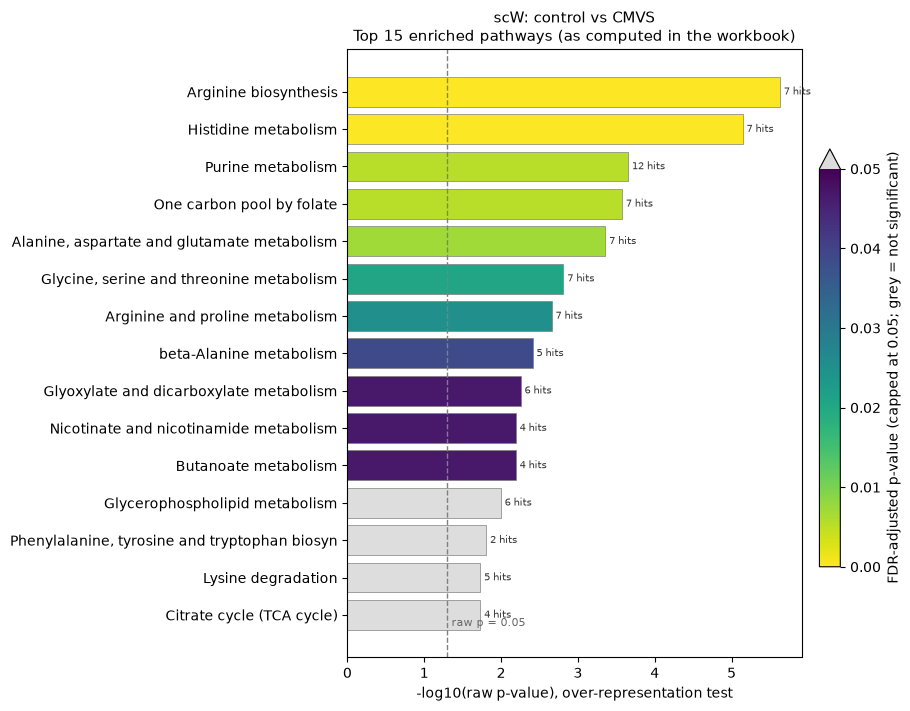

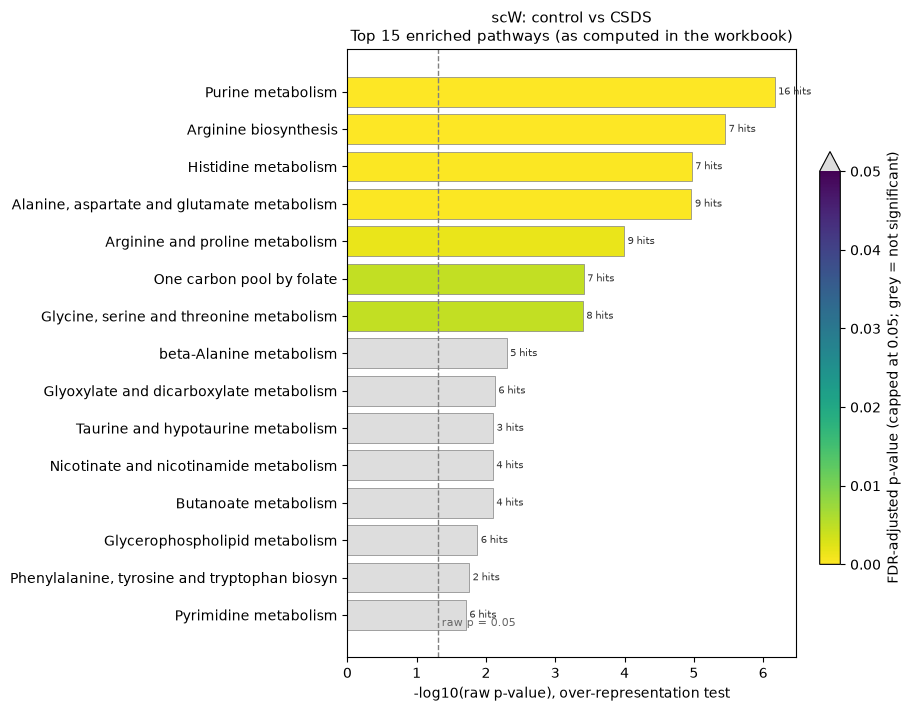

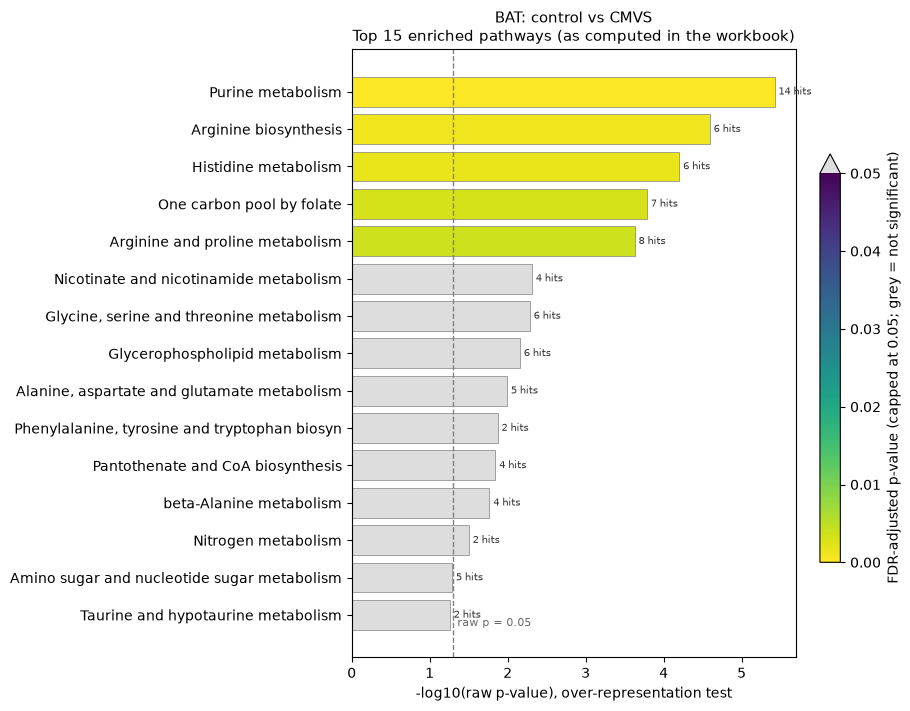

In [12]:
def plot_enrichment_bar(table, title, top_n=15):
    if len(table) == 0:
        print(f"No pathway table available for {title}.")
        return

    ranked = table.nsmallest(top_n, "p-value").iloc[::-1]  # smallest p at top of the plot
    y_pos = np.arange(len(ranked))
    neg_log_p = -np.log10(ranked["p-value"].astype(float).clip(lower=1e-300))
    fdr = ranked["Adjused p-value (FDR)"].astype(float)

    fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(ranked) + 1)), layout="constrained")

    # Same capped-at-0.05 colour scale as the bubble plot above, for the
    # same reason: almost every pathway's FDR sits near 1, so a 0-1 scale
    # wastes nearly all its resolution on values nobody needs to tell apart.
    fdr_norm = mcolors.Normalize(vmin=0, vmax=0.05, clip=False)
    bar_cmap = plt.cm.viridis_r.copy()
    bar_cmap.set_over("#dddddd")

    bars = ax.barh(y_pos, neg_log_p, color=bar_cmap(fdr_norm(fdr)), edgecolor="grey", linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ranked.iloc[:, 0].astype(str).str.slice(0, 45))
    ax.axvline(-np.log10(0.05), linestyle="--", color="grey", linewidth=1)
    ax.annotate("raw p = 0.05", xy=(-np.log10(0.05), 0), xytext=(3, -8), textcoords="offset points",
                fontsize=8, color="dimgrey")

    for bar, hits in zip(bars, ranked["Hits"].astype(int)):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"{hits} hits", va="center", fontsize=7.5, color="#333333")

    sm = plt.cm.ScalarMappable(cmap=bar_cmap, norm=fdr_norm)
    cb = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.02, extend="max")
    cb.set_label("FDR-adjusted p-value (capped at 0.05; grey = not significant)")

    ax.set_xlabel("-log10(raw p-value), over-representation test")
    ax.set_title(f"{title}\nTop {len(ranked)} enriched pathways (as computed in the workbook)", fontsize=11)
    plt.show()


for (tissue, case), table in pathway_tables.items():
    plot_enrichment_bar(table, f"{tissue}: control vs {case}")

### If you want this notebook to compute enrichment itself

Two ways to unblock `hypergeometric_ora` above with real data:

1. **Grant KEGG access** for this environment (or run this notebook
   somewhere with outbound internet), so a live
   `compound -> pathway` map can be pulled directly (e.g. via
   `rest.kegg.jp/link/pathway/<compound_id>` for each KEGG ID in the
   `Annotation` sheet).
2. **Supply a mapping file** — export a KEGG compound-to-pathway table
   yourself (MetaboAnalyst's own pathway module can export the library it
   used) and drop it in this repository; point `hypergeometric_ora` at it
   and it will run directly against this notebook's own FDR<0.05 hit lists
   for all four comparisons, including BAT/CSDS (which would correctly
   return no enriched pathways, since it has no significant metabolites to
   test in the first place).

## Summary

* **scW responds robustly to CMVS** (75 FDR-significant metabolites, all
  elevated); its response to CSDS is marginal (2 hits).
* **BAT's response is weak under both stressors** (3 FDR-significant
  metabolites for CMVS, 0 for CSDS) — despite PLS-DA models that look clean
  by R2Y alone; permutation testing shows none of the four models beat
  chance at p < 0.05.
* Pathway-level enrichment is available, from the workbook's pre-existing
  MetaboAnalyst run, for 3 of 4 comparisons — but against a looser,
  VIP-inclusive hit list than this notebook's own FDR-only significance
  rule. Treat the two as answering related but not identical questions
  until enrichment can be recomputed directly against this notebook's own
  hit lists (see above for what that requires).
* Full per-metabolite tables: `results/significant_metabolites_by_comparison.xlsx`.
  Full methodology and rationale: `ANALYSIS.md`.